In [281]:
import numpy as np
xf_train = np.load("processed-imgs/xf_train.npy")
xf_test = np.load("processed-imgs/xf_test.npy")
y_train = np.load("processed-imgs/y_train.npy")
y_test = np.load("processed-imgs/y_test.npy")
xi_train = np.load("processed-imgs/xi_train.npy")
xi_test = np.load("processed-imgs/xi_test.npy")
x_train_scaled = np.load("processed-imgs/xf_train_scaled.npy")
x_test_scaled = np.load("processed-imgs/xf_test_scaled.npy")


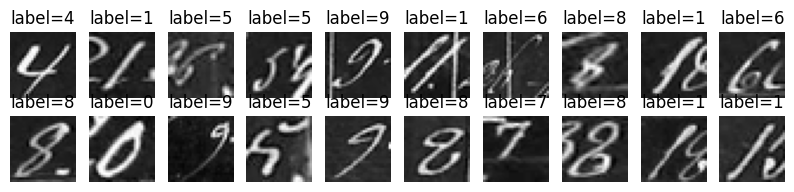

In [282]:
from plot_sample import plot_sample
plot_sample(xi_train, y_train)

#### Helper Function 

In [ ]:
import matplotlib.pyplot as plt
def plt_loss_curve(x):
    import matplotlib.pyplot as plt
    plt.plot(x)
    plt.title('Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.show()

def tradeoff_plot(loss , val):
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Epochs (Iterations)')
    ax1.set_ylabel('Training Loss', color=color)
    ax1.plot(loss, color=color, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel('Validation Accuracy', color=color)
    ax2.plot(val, color=color, label='Validation Score')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title("Training Loss vs. Validation Accuracy (mlp12_7)")
    ax1.grid(True, alpha=0.3)
    fig.tight_layout() 
    plt.show()
        

#Multinomial

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import  cross_validate
from time import time
mlp = MLPClassifier(solver='sgd', 
    learning_rate='constant', 
    max_iter=1000, 
    random_state=42)



In [4]:
help(MLPClassifier)

Help on class MLPClassifier in module sklearn.neural_network._multilayer_perceptron:

class MLPClassifier(sklearn.base.ClassifierMixin, BaseMultilayerPerceptron)
 |  MLPClassifier(hidden_layer_sizes=(100,), activation='relu', *, solver='adam', alpha=0.0001, batch_size='auto', learning_rate='constant', learning_rate_init=0.001, power_t=0.5, max_iter=200, shuffle=True, random_state=None, tol=0.0001, verbose=False, warm_start=False, momentum=0.9, nesterovs_momentum=True, early_stopping=False, validation_fraction=0.1, beta_1=0.9, beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000)
 |
 |  Multi-layer Perceptron classifier.
 |
 |  This model optimizes the log-loss function using LBFGS or stochastic
 |  gradient descent.
 |
 |  .. versionadded:: 0.18
 |
 |  Parameters
 |  ----------
 |  hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
 |      The ith element represents the number of neurons in the ith
 |      hidden layer.
 |
 |  activation : {'identity', '

In [291]:
mlp1=MLPClassifier(activation='logistic', alpha=0.0001, hidden_layer_sizes=(100, 100), learning_rate='constant', learning_rate_init=0.01, max_iter=1000, random_state=42, solver='sgd')
mlp1.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'logistic'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


1.0
0.8015


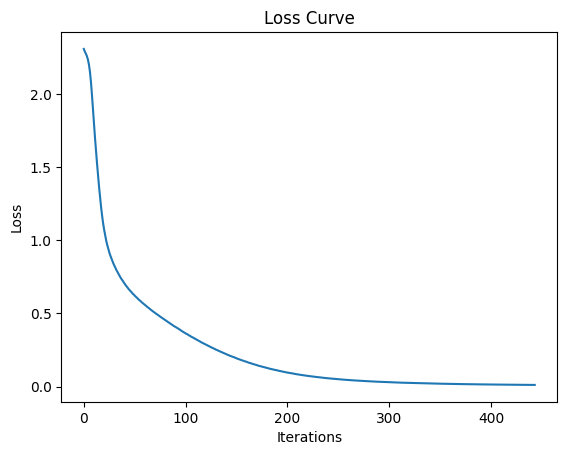

In [292]:
print(mlp1.score(x_train_scaled , y_train))
print(mlp1.score(x_test_scaled , y_test))
plt_loss_curve(mlp1.loss_curve_)

In [290]:
print(mlp1.n_outputs_)
mlp1.out_activation_

10


'softmax'

In [ ]:
mlp2=MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(100, 100), learning_rate='constant', learning_rate_init=0.01, max_iter=500,  random_state=42, solver='sgd')
mlp2.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


1.0
0.8425


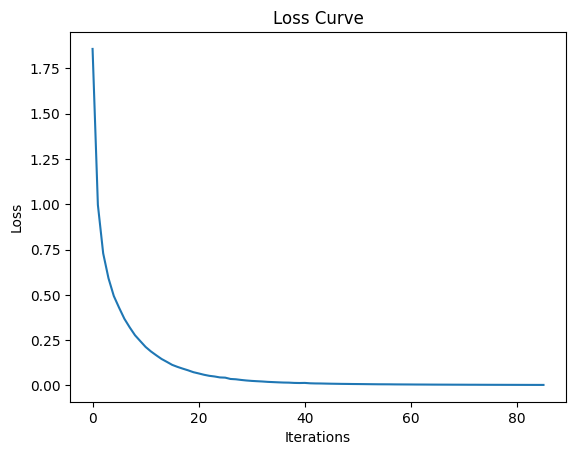

In [7]:
print(mlp2.score(x_train_scaled , y_train))
print(mlp2.score(x_test_scaled , y_test))
plt_loss_curve(mlp2.loss_curve_)

In [ ]:
mlp3=MLPClassifier(activation='tanh', alpha=0.0001, hidden_layer_sizes=(100, 100), learning_rate='constant', learning_rate_init=0.01, max_iter=500, random_state=42, solver='sgd')
mlp3.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'tanh'
,solver,'sgd'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42


1.0
0.79


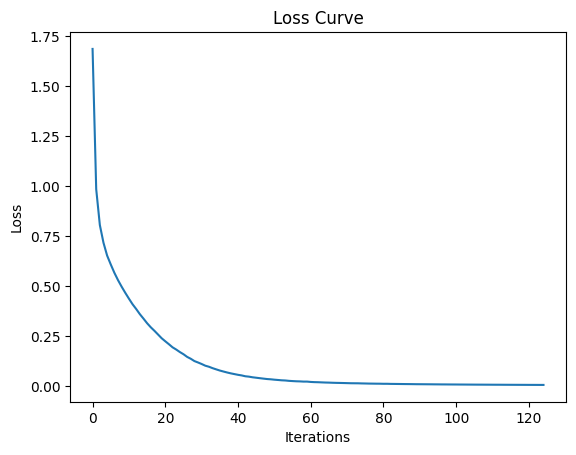

In [9]:
print(mlp3.score(x_train_scaled , y_train))
print(mlp3.score(x_test_scaled , y_test))
plt_loss_curve(mlp3.loss_curve_)

In [ ]:
mlp5=MLPClassifier(activation='relu', alpha=0.001, hidden_layer_sizes=(100, 50), learning_rate='constant', learning_rate_init=0.01, max_iter=1000,batch_size=32,  random_state=42, solver='sgd')
mlp5.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.001
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


1.0
0.8665


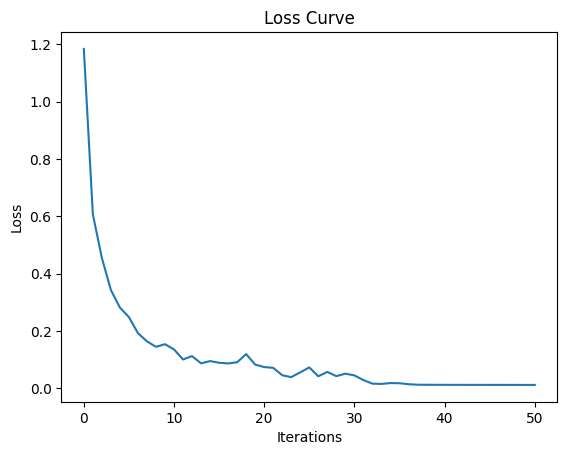

In [12]:
print(mlp5.score(x_train_scaled , y_train))
print(mlp5.score(x_test_scaled , y_test))
plt_loss_curve(mlp5.loss_curve_)

In [ ]:
mlp6=MLPClassifier(activation='relu', alpha=0.01, hidden_layer_sizes=(50,50), learning_rate='constant', learning_rate_init=0.01, max_iter=1000,batch_size=32, random_state=42, solver='sgd')
mlp6.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.01
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.99975
0.8485


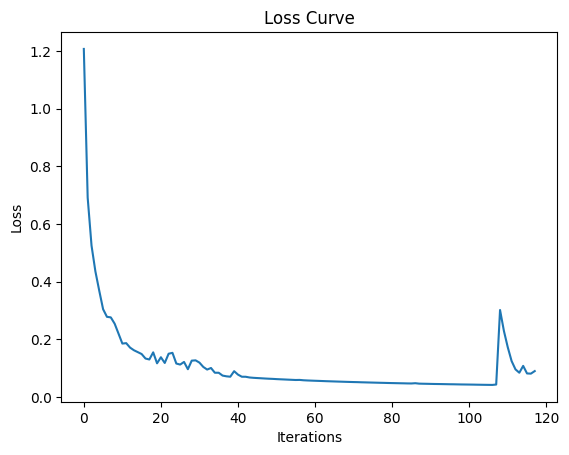

In [14]:
print(mlp6.score(x_train_scaled , y_train))
print(mlp6.score(x_test_scaled , y_test))
plt_loss_curve(mlp6.loss_curve_)

In [293]:
mlp7=MLPClassifier(activation='relu', alpha=0.01, hidden_layer_sizes=(50,50), learning_rate='constant', learning_rate_init=0.001, max_iter=1000,batch_size=32,random_state=42, solver='sgd')
mlp7.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.01
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


1.0
0.8185


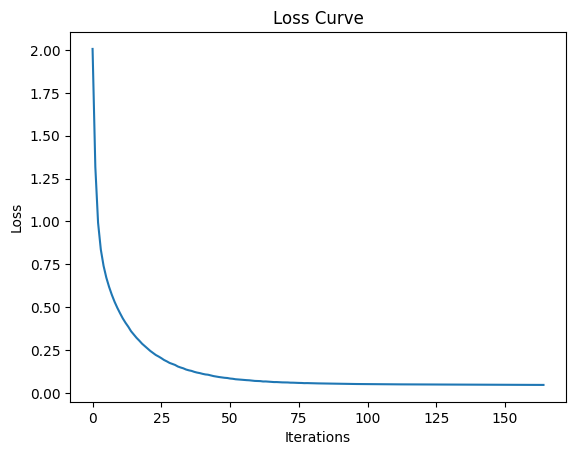

In [294]:
print(mlp7.score(x_train_scaled , y_train))
print(mlp7.score(x_test_scaled , y_test))
plt_loss_curve(mlp7.loss_curve_)

In [ ]:
mlp8=MLPClassifier(activation='relu', alpha=0.05, hidden_layer_sizes=(50,50), learning_rate='constant', learning_rate_init=0.001, max_iter=1000,batch_size=32,early_stopping=True, momentum=0.9,  solver='sgd')
mlp8.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.05
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.970125
0.821


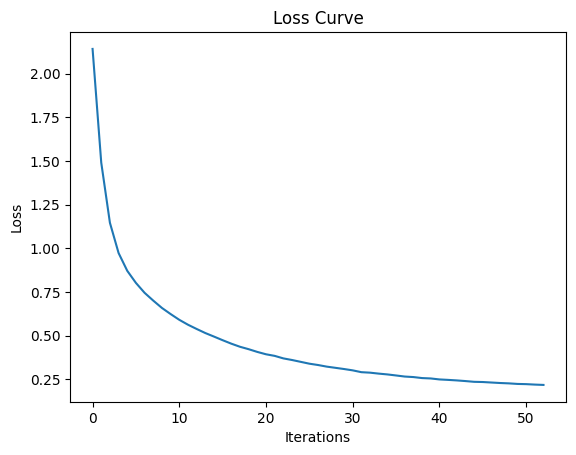

In [19]:
print(mlp8.score(x_train_scaled , y_train))
print(mlp8.score(x_test_scaled , y_test))
plt_loss_curve(mlp8.loss_curve_)

In [ ]:
mlp9=MLPClassifier(activation='relu', alpha=0.05, hidden_layer_sizes=(100,50), learning_rate='constant', learning_rate_init=0.01,early_stopping=True, max_iter=1000,batch_size=32,  random_state=42, solver='sgd')
mlp9.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.05
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.98675
0.8655


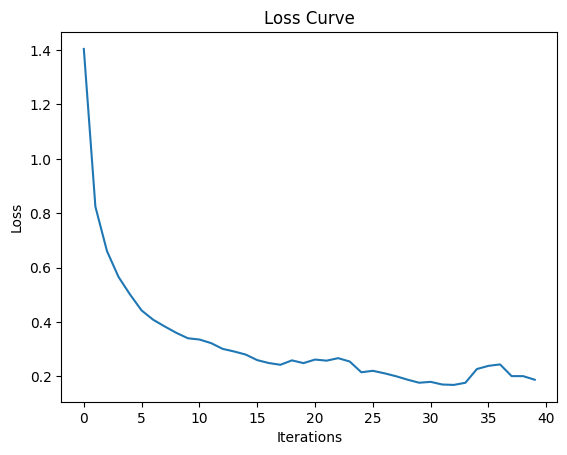

In [21]:
print(mlp9.score(x_train_scaled , y_train))
print(mlp9.score(x_test_scaled , y_test))
plt_loss_curve(mlp9.loss_curve_)

In [ ]:
mlp10=MLPClassifier(activation='relu', alpha=0.1, hidden_layer_sizes=(100,50), learning_rate='constant', learning_rate_init=0.001,early_stopping=True, max_iter=1000,batch_size=64, momentum=0.9,  solver='sgd')
mlp10.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.1
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.97
0.827


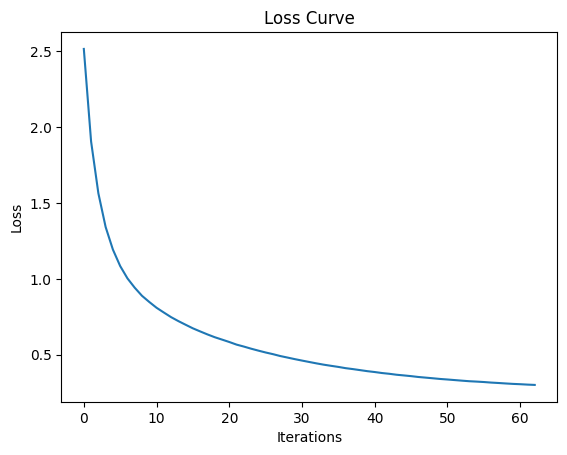

In [27]:
print(mlp10.score(x_train_scaled , y_train))
print(mlp10.score(x_test_scaled , y_test))
plt_loss_curve(mlp10.loss_curve_)

In [ ]:
mlp11=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(100,50), learning_rate='constant', learning_rate_init=0.001,early_stopping=True, max_iter=1000,batch_size=32,  random_state=42, solver='sgd')
mlp11.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.95525
0.8555


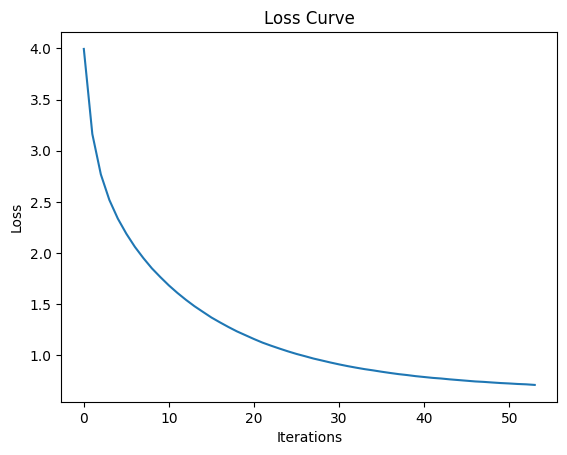

In [30]:
print(mlp11.score(x_train_scaled , y_train))
print(mlp11.score(x_test_scaled , y_test))
plt_loss_curve(mlp11.loss_curve_)

In [84]:
mlp12=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(100,50), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.980875
0.8775


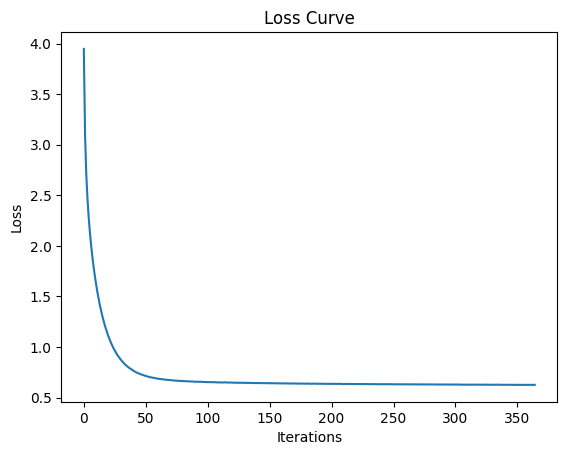

In [85]:
print(mlp12.score(x_train_scaled , y_train))
print(mlp12.score(x_test_scaled , y_test))
plt_loss_curve(mlp12.loss_curve_)

In [226]:
mlp12_=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(64,32), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12_.fit(x_train_scaled , y_train)  


,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.973875
0.8625


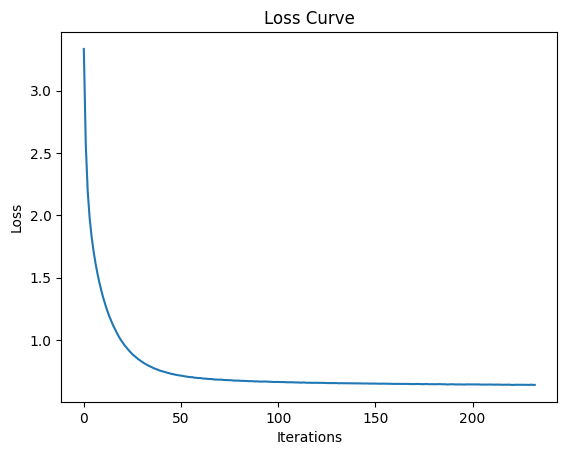

In [227]:
print(mlp12_.score(x_train_scaled , y_train))
print(mlp12_.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_.loss_curve_)

In [228]:
mlp12_1=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(256,128), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12_1.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.985125
0.881


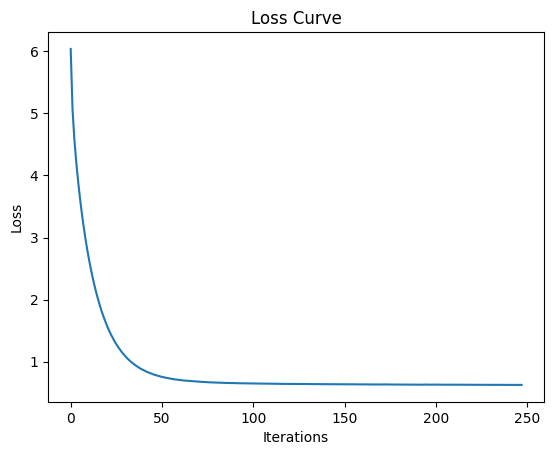

In [229]:
print(mlp12_1.score(x_train_scaled , y_train))
print(mlp12_1.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_1.loss_curve_)

In [233]:
mlp12_2=MLPClassifier(activation='relu', alpha=0.05, hidden_layer_sizes=(256,128), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12_2.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(256, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.05
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


1.0
0.877


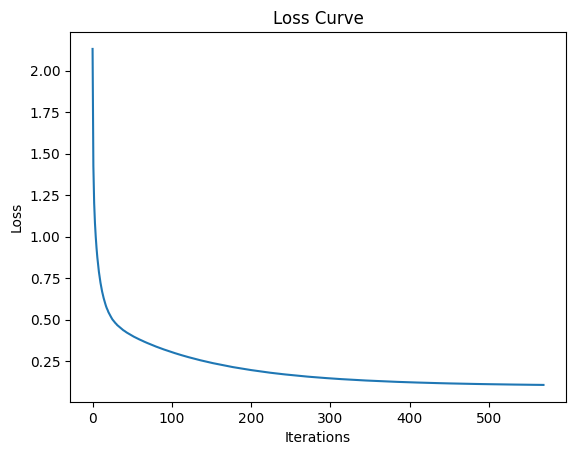

In [234]:
print(mlp12_2.score(x_train_scaled , y_train))
print(mlp12_2.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_2.loss_curve_)

In [236]:
mlp12_3=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(512,256,128), learning_rate='adaptive', learning_rate_init=0.01,early_stopping=True, max_iter=1000,batch_size=64, momentum=0.9, random_state=42, solver='sgd')
mlp12_3.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,64
,learning_rate,'adaptive'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.989375
0.8805


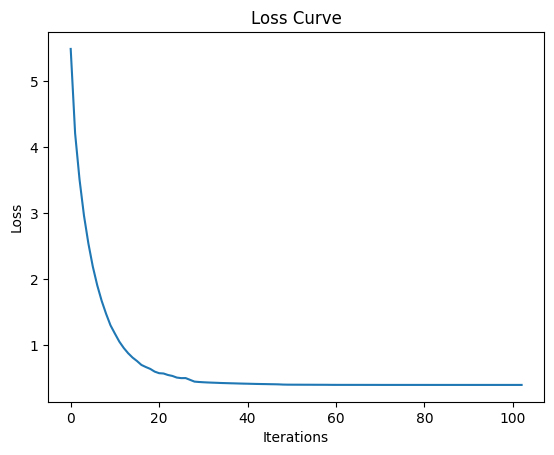

In [242]:
print(mlp12_3.score(x_train_scaled , y_train))
print(mlp12_3.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_3.loss_curve_)

In [238]:
mlp12_4=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(512,256,128), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=64, momentum=0.9, random_state=42, solver='sgd')
mlp12_4.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.999625
0.877


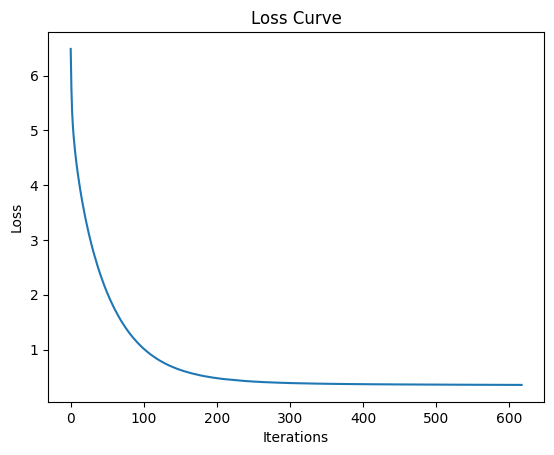

In [239]:
print(mlp12_4.score(x_train_scaled , y_train))
print(mlp12_4.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_4.loss_curve_)

In [240]:
#to avoid vanishing
mlp12_5=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(512,256), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=64, momentum=0.9, random_state=42, solver='sgd')
mlp12_5.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.99825
0.883


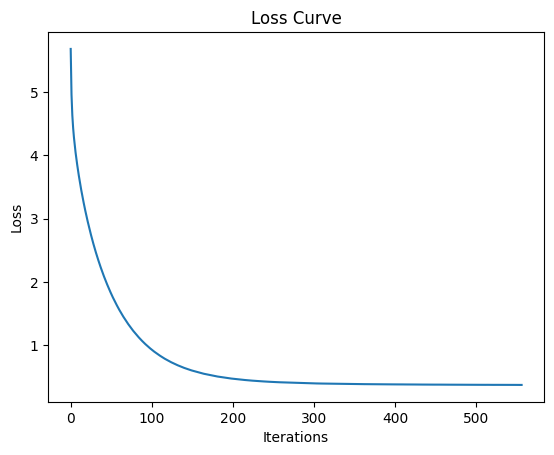

In [241]:
print(mlp12_5.score(x_train_scaled , y_train))
print(mlp12_5.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_5.loss_curve_)

In [248]:
#to avoid vanishing
mlp12_6=MLPClassifier(activation='relu', alpha=0.3, hidden_layer_sizes=(512,256), learning_rate='adaptive', learning_rate_init=0.01,early_stopping=True, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12_6.fit(x_train_scaled , y_train)


,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.3
,batch_size,32
,learning_rate,'adaptive'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.981375
0.886


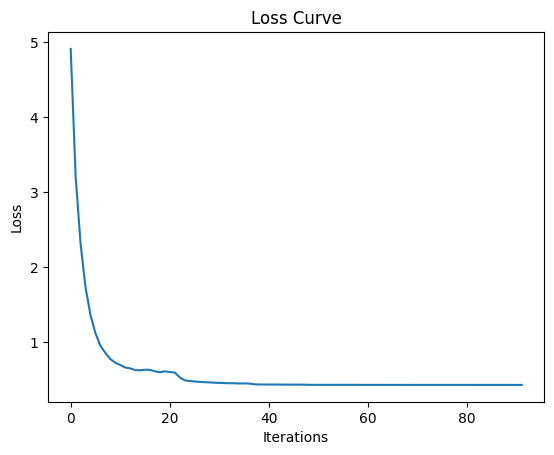

In [249]:
print(mlp12_6.score(x_train_scaled , y_train))
print(mlp12_6.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_6.loss_curve_)

In [252]:
#to avoid vanishing
mlp12_7=MLPClassifier(activation='relu', alpha=0.2, hidden_layer_sizes=(512,256), learning_rate='adaptive', learning_rate_init=0.01,early_stopping=True, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp12_7.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(512, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.2
,batch_size,32
,learning_rate,'adaptive'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.987375
0.891


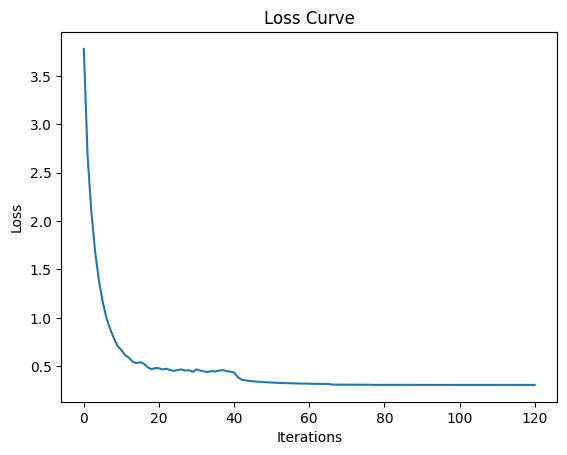

In [253]:
print(mlp12_7.score(x_train_scaled , y_train))
print(mlp12_7.score(x_test_scaled , y_test))
plt_loss_curve(mlp12_7.loss_curve_)

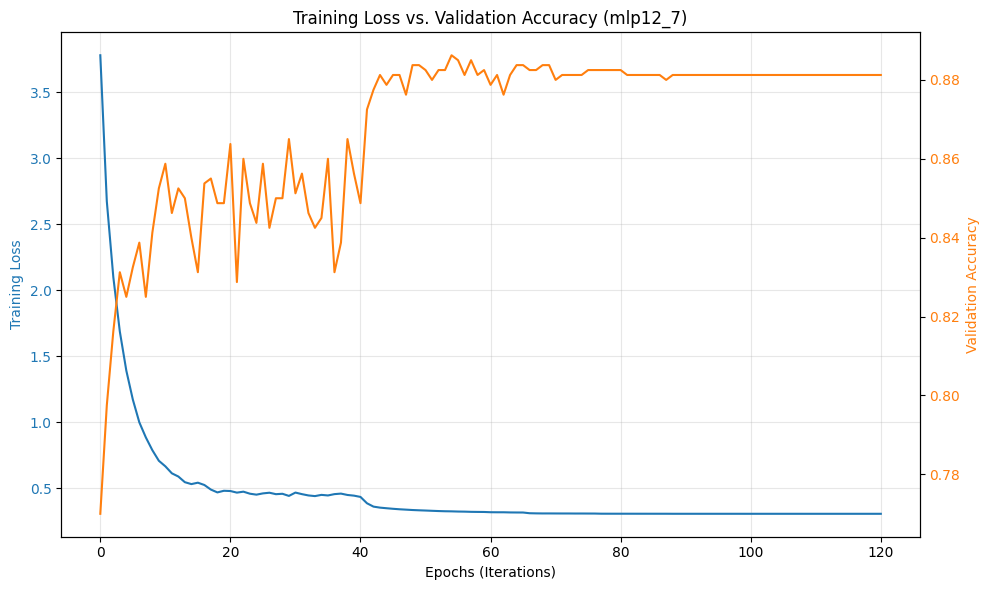

In [260]:
tradeoff_plot(mlp12_7.loss_curve_ , mlp12_7.validation_scores_)

In [208]:
mlp13=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(20,10), learning_rate='constant', learning_rate_init=0.001,early_stopping=False, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp13.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(20, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.939625
0.841


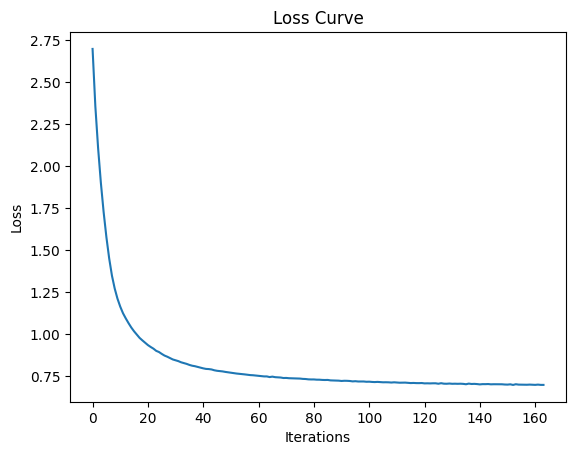

In [210]:
print(mlp13.score(x_train_scaled , y_train))
print(mlp13.score(x_test_scaled , y_test))
plt_loss_curve(mlp13.loss_curve_)

In [224]:
mlp14=MLPClassifier(activation='relu', alpha=0.5, hidden_layer_sizes=(10,5), learning_rate='constant', learning_rate_init=0.001,early_stopping=True, max_iter=1000,batch_size=32, momentum=0.9, random_state=42, solver='sgd')
mlp14.fit(x_train_scaled , y_train)

,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.5
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


0.800125
0.7445


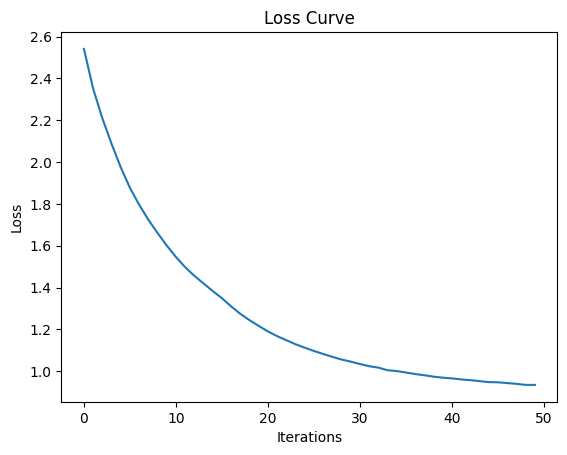

In [225]:
print(mlp14.score(x_train_scaled , y_train))
print(mlp14.score(x_test_scaled , y_test))
plt_loss_curve(mlp14.loss_curve_)

In [ ]:
start = time()
kf_scores=cross_validate(mlp12_7, x_train_scaled, y_train, cv=5, scoring='accuracy',return_train_score=True
,verbose=5555)
time_mlp_sgd_kf = time() - start
print(f"KFold Cross-validation train time: {time_mlp_sgd_kf:.2f} seconds")
print(f"KFold Cross-validation train Accuracy scores: {kf_scores['train_score']}")
print(f"KFold Cross-validation test Accuracy scores: {kf_scores['test_score']}")

[CV] START .....................................................................
[CV] END ..................., score=(train=0.988, test=0.876) total time= 6.0min
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:  6.0min
[CV] START .....................................................................
[CV] END ..................., score=(train=0.989, test=0.880) total time= 6.5min
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed: 12.5min
[CV] START .....................................................................
[CV] END ..................., score=(train=0.990, test=0.871) total time= 4.0min
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed: 16.5min
[CV] START .....................................................................
[CV] END ..................., score=(train=0.987, test=0.884) total time= 4.8min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed: 21.3min
[CV] START .....................................................................
[CV] END ..................

In [262]:
avg_kf_score_mlp_sgd_train = np.mean(kf_scores['train_score'])
print(f"Average KFold Cross-validation train Accuracy: {avg_kf_score_mlp_sgd_train:.4f}")
std_kf_score_mlp_sgd_train = np.std(kf_scores['train_score'])
print(f"Standard Deviation of KFold Cross-validation train Accuracy: {std_kf_score_mlp_sgd_train:.4f}")

avg_kf_score_mlp_sgd_test = np.mean(kf_scores['test_score'])
print(f"Average KFold Cross-validation test Accuracy: {avg_kf_score_mlp_sgd_test:.4f}")
std_kf_score_mlp_sgd_test = np.std(kf_scores['test_score'])
print(f"Standard Deviation of KFold Cross-validation  test Accuracy: {std_kf_score_mlp_sgd_test:.4f}")

Average KFold Cross-validation train Accuracy: 0.9880
Standard Deviation of KFold Cross-validation train Accuracy: 0.0014
Average KFold Cross-validation test Accuracy: 0.8722
Standard Deviation of KFold Cross-validation  test Accuracy: 0.0120


In [263]:
start = time()
mlp12_7.fit(x_train_scaled, y_train)
time_mlp_sgd_kf += time() - start

In [264]:
y_test_pred = mlp12_7.predict(x_test_scaled)
y_train_pred = mlp12_7.predict(x_train_scaled)
y_test_pred

array([7, 5, 3, ..., 2, 0, 9], dtype=int64)

In [274]:
sum(mlp12_7.predict_proba(x_test_scaled)[999])

1.0000000236846418

In [266]:
print(f"MLP SGD Multinomial Train Accuracy: {mlp12_7.score(x_train_scaled, y_train):.4f}")

print(f"MLP SGD Multinomial Test Accuracy: {mlp12_7.score(x_test_scaled, y_test):.4f}")

MLP SGD Multinomial Train Accuracy: 0.9874
MLP SGD Multinomial Test Accuracy: 0.8910


In [267]:
from cmetrics import *
accuracy_mlp_sgd = acc(y_test, y_test_pred)
print(f"MLP SGD Multi Accuracy: {accuracy_mlp_sgd:.4f}%")
prec_mlp_sgd = precision(y_test, y_test_pred)
print(f"MLP SGD Multi Precision: {prec_mlp_sgd:.4f}%")
rec_mlp_sgd = recall(y_test, y_test_pred)
print(f"MLP SGD Multi Recall: {rec_mlp_sgd:.4f}%")
f1_score_mlp_sgd = f1(y_test, y_test_pred)
print(f"MLP SGD Multi F1 Score: {f1_score_mlp_sgd:.4f}%")

MLP SGD Multi Accuracy: 89.1000%
MLP SGD Multi Precision: 89.1758%
MLP SGD Multi Recall: 89.1000%
MLP SGD Multi F1 Score: 89.0700%


In [268]:
import json

metrics = {
    "accuracy": accuracy_mlp_sgd,
    "precision": prec_mlp_sgd,
    "recall": rec_mlp_sgd,
    "f1_score": f1_score_mlp_sgd,
    "train_time": time_mlp_sgd_kf
}

with open("experiments/mlp_sgd.json", "w") as f:
    json.dump(metrics, f, indent=4)


In [269]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.95      0.92       200
           1       0.87      0.93      0.90       200
           2       0.92      0.88      0.90       200
           3       0.89      0.86      0.88       200
           4       0.88      0.88      0.88       200
           5       0.95      0.91      0.93       200
           6       0.91      0.94      0.93       200
           7       0.88      0.90      0.89       200
           8       0.90      0.81      0.85       200
           9       0.83      0.86      0.85       200

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



In [270]:
cm=conf_matrix(y_test, y_test_pred)
cm

array([[191,   2,   0,   1,   0,   0,   3,   0,   0,   3],
       [  1, 186,   2,   2,   1,   0,   1,   6,   0,   1],
       [  1,   5, 176,   4,   3,   1,   0,   3,   2,   5],
       [  6,   2,   5, 172,   2,   3,   0,   1,   6,   3],
       [  0,   7,   2,   0, 175,   0,   5,   1,   3,   7],
       [  2,   1,   1,   2,   1, 181,   5,   4,   2,   1],
       [  3,   1,   0,   0,   1,   4, 189,   0,   2,   0],
       [  1,   4,   0,   0,   3,   0,   1, 179,   2,  10],
       [  9,   4,   4,   3,   4,   2,   4,   5, 161,   4],
       [  3,   1,   2,   9,   8,   0,   0,   4,   1, 172]], dtype=int64)

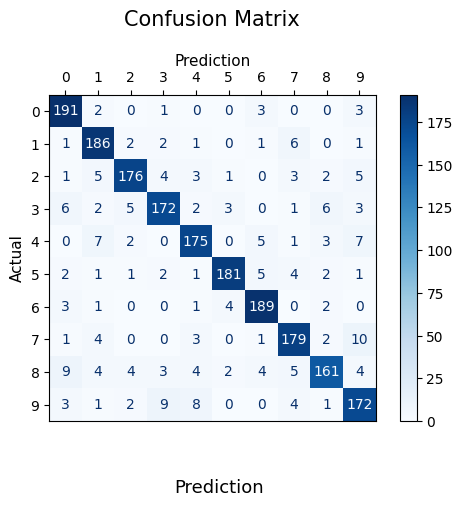

In [271]:
plot_confusion_matrix(cm)